In [1]:
import yfinance as yf

ticker_symbol = '^IXIC'
start_date = '2019-01-01'

nasdaq_data = yf.download(ticker_symbol, start=start_date)

print("NASDAQ Composite Index data downloaded successfully.")
print(nasdaq_data.head())

print('Missing values per column:')
display(nasdaq_data.isnull().sum())

print('\nTotal rows:', nasdaq_data.shape[0])
print('Total columns:', nasdaq_data.shape[1])



/tmp/ipython-input-251/2684802224.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq_data = yf.download(ticker_symbol, start=start_date)
[*********************100%***********************]  1 of 1 completed

NASDAQ Composite Index data downloaded successfully.
Price             Close         High          Low         Open      Volume
Ticker            ^IXIC        ^IXIC        ^IXIC        ^IXIC       ^IXIC
Date                                                                      
2019-01-02  6665.939941  6693.709961  6506.879883  6506.910156  2261800000
2019-01-03  6463.500000  6600.209961  6457.129883  6584.770020  2631550000
2019-01-04  6738.859863  6760.689941  6554.240234  6567.140137  2596150000
2019-01-07  6823.470215  6855.600098  6741.399902  6757.529785  2523450000
2019-01-08  6897.000000  6909.580078  6795.859863  6893.439941  2407340000
Missing values per column:


,,0
Price,Ticker,
Close,^IXIC,0
High,^IXIC,0
Low,^IXIC,0
Open,^IXIC,0
Volume,^IXIC,0



Total rows: 1797
Total columns: 5


In [8]:
comparison_df = pd.DataFrame({
    'Actual': aligned_test['price'],
    'Predicted': aligned_forecast['yhat'],
    'Difference': aligned_test['price'] - aligned_forecast['yhat'],
    'Error (%)': (np.abs(aligned_test['price'] - aligned_forecast['yhat']) / aligned_test['price']) * 100
})

print("Comparison of Actual vs Predicted Values (First 10 rows):")
display(comparison_df.head(10))

print("\nComparison of Actual vs Predicted Values (Last 10 rows):")
display(comparison_df.tail(10))

Comparison of Actual vs Predicted Values (First 10 rows):


,Actual,Predicted,Difference,Error (%)
Date,,,,
2024-09-18,17573.300781,17590.786228,-17.485447,0.099500
2024-09-19,18013.980469,17574.636425,439.344044,2.438906
2024-09-20,17948.320312,17560.081485,388.238828,2.163093
2024-09-23,17974.269531,17526.940627,447.328904,2.488718
2024-09-24,18074.519531,17519.559275,554.960256,3.070401
2024-09-25,18082.210938,17514.012019,568.198918,3.142309
2024-09-26,18190.289062,17510.256659,680.032403,3.738436
2024-09-27,18119.589844,17508.225795,611.364048,3.374050
2024-09-30,18189.169922,17511.496838,677.673084,3.725695



Comparison of Actual vs Predicted Values (Last 10 rows):


,Actual,Predicted,Difference,Error (%)
Date,,,,
2025-08-29,21455.550781,21893.435760,-437.884979,2.040894
2025-09-02,21279.630859,21882.134694,-602.503834,2.831364
2025-09-03,21497.730469,21873.013371,-375.282902,1.745686
2025-09-04,21707.689453,21861.578452,-153.888999,0.708915
2025-09-05,21700.390625,21847.997888,-147.607263,0.680206
2025-09-08,21798.699219,21796.523156,2.176063,0.009983
2025-09-09,21879.490234,21776.623909,102.866326,0.470150
2025-09-10,21886.060547,21755.816789,130.243758,0.595099
2025-09-11,22043.070312,21734.394866,308.675447,1.400329


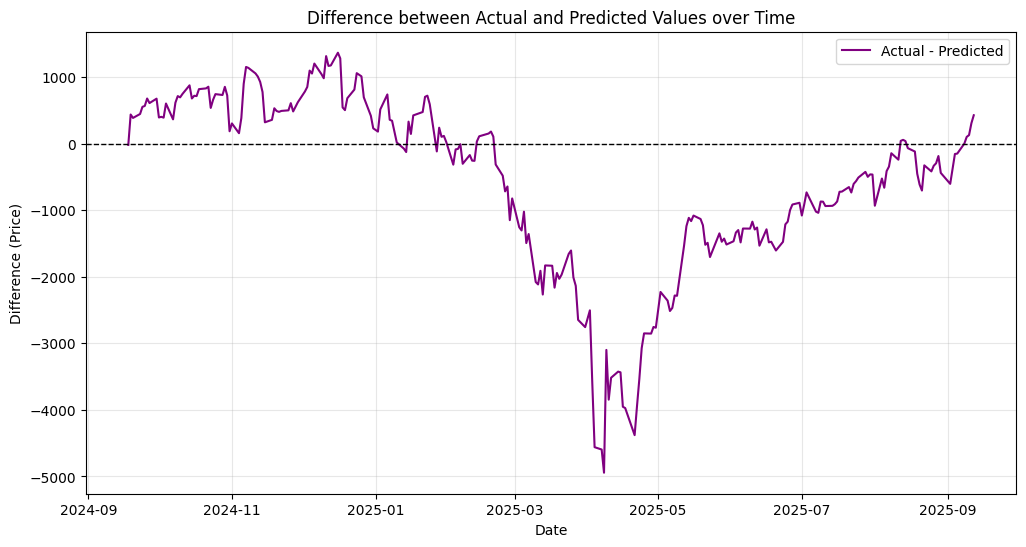

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Difference'], label='Actual - Predicted', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # Add a horizontal line at 0 for reference
plt.title('Difference between Actual and Predicted Values over Time')
plt.xlabel('Date')
plt.ylabel('Difference (Price)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure indices match for comparison
aligned_test = test.reindex(forecast_test.index).dropna()
aligned_forecast = forecast_test.loc[aligned_test.index]

y_true = aligned_test['price']
y_pred = aligned_forecast['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 1072.80
Root Mean Squared Error (RMSE): 1446.54


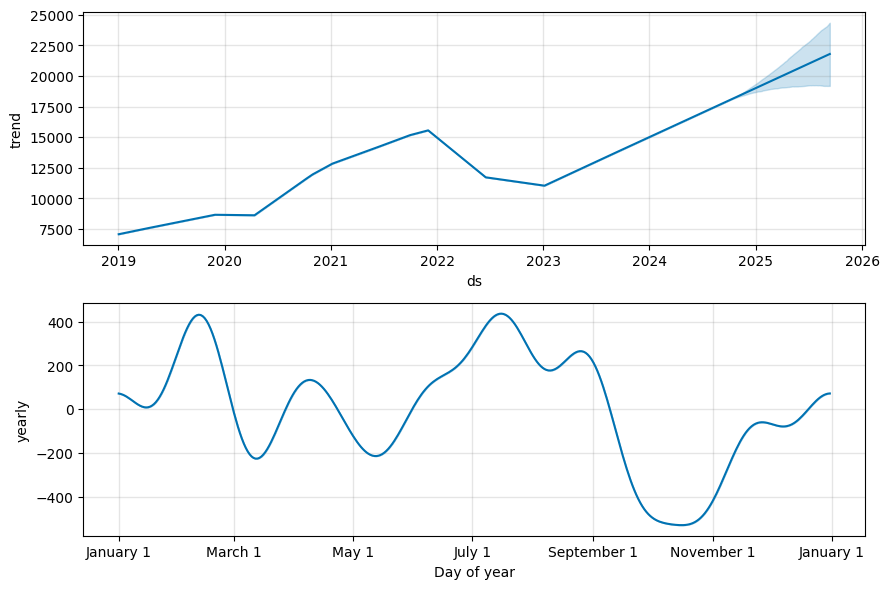

In [6]:
fig2 = prophet_model.plot_components(forecast.reset_index())
plt.show()

In [2]:
import pandas as pd
from prophet import Prophet


nasdaq_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in nasdaq_data.columns.values]


prophet_df = nasdaq_data[['Close_^IXIC']].copy()
prophet_df.columns = ['price']


train_size = int(len(prophet_df) * 0.8)
train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train['price'].values
  })

print("Fitting Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test), freq='D')

forecast = prophet_model.predict(future)

forecast.set_index('ds', inplace=True)

forecast_test = forecast.reindex(test.index).copy()

forecast_test = forecast_test.dropna()

Fitting Prophet model...


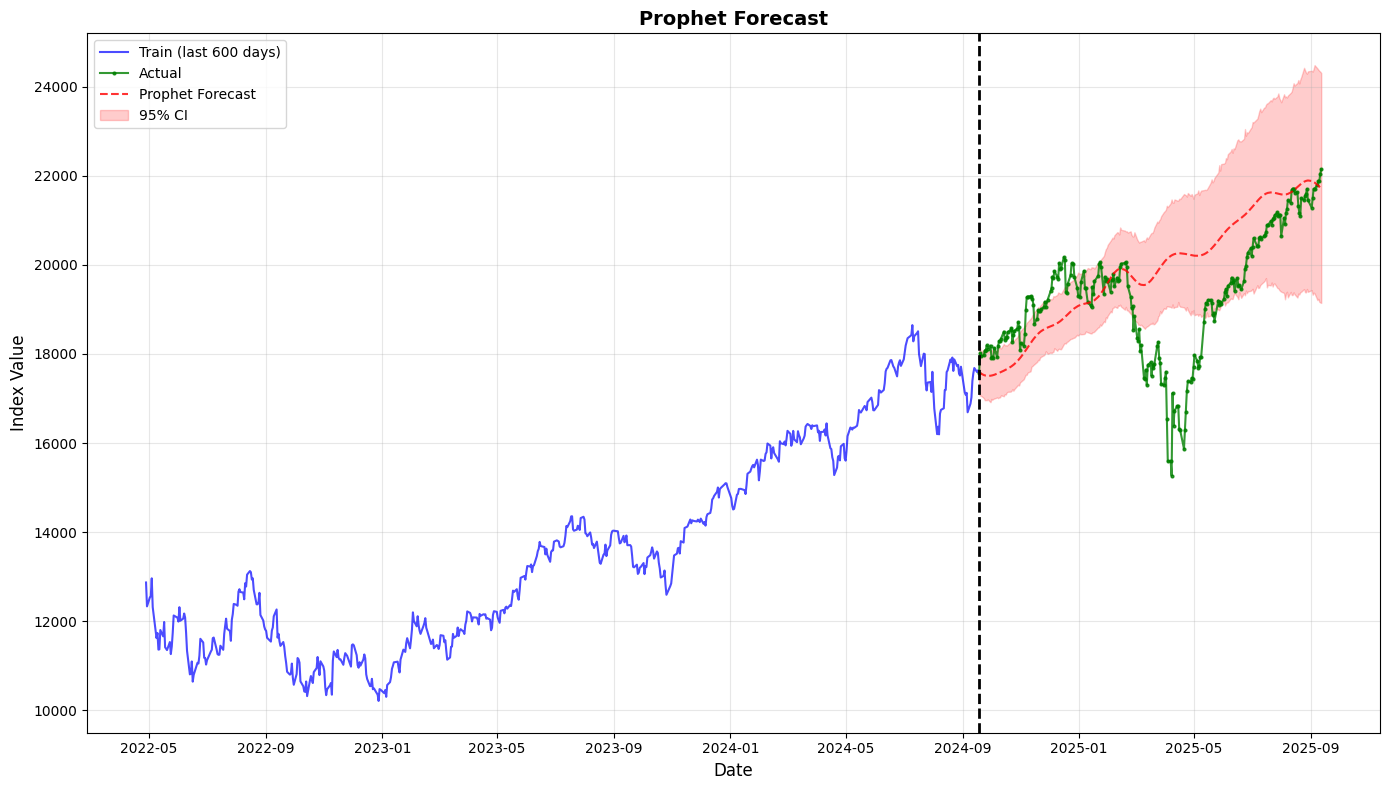

In [3]:
import matplotlib.pyplot as plt

split_date = test.index.min()

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.plot(train.index[-600:], train['price'][-600:], linewidth=1.5, alpha=0.7,
        color='blue', label='Train (last 600 days)')
aligned_test_plot = test.reindex(forecast_test.index).dropna()
ax.plot(aligned_test_plot.index, aligned_test_plot['price'], linewidth=1.5, alpha=0.8,
        color='green', label='Actual', marker='o', markersize=2)
ax.plot(forecast_test.index, forecast_test['yhat'], linewidth=1.5, alpha=0.8,
        color='red', linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast_test.index,
                 forecast_test['yhat_lower'],
                 forecast_test['yhat_upper'],
                 alpha=0.2, color='red', label='95% CI')
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)
ax.set_title('Prophet Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
import datetime
import pandas as pd


today = datetime.date.today()


future_dates_list = []
current_date = today
while len(future_dates_list) < 5:
    current_date += datetime.timedelta(days=1)

    future_dates_list.append(current_date)

future_5_days_from_today = pd.DataFrame({'ds': future_dates_list})


forecast_5_days_from_today = prophet_model.predict(future_5_days_from_today)

print(f"5-day ahead forecast for NASDAQ starting from {today + datetime.timedelta(days=1)}:")
display(forecast_5_days_from_today[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

5-day ahead forecast for NASDAQ starting from 2026-02-26:


,ds,yhat,yhat_lower,yhat_upper
0,2026-02-26,23719.581814,23214.505993,24261.540450
1,2026-02-27,23694.834561,23170.185032,24247.857800
2,2026-02-28,23670.684891,23110.396580,24202.998159
3,2026-03-01,23647.559236,23087.290411,24216.182452
4,2026-03-02,23625.863586,23064.759321,24212.507170


In [10]:
rolling_df = nasdaq_data[['Close_^IXIC']].copy()
rolling_df.reset_index(inplace=True)
rolling_df.columns = ['ds', 'y']

rolling_df['ds'] = pd.to_datetime(rolling_df['ds'])
rolling_df = rolling_df.sort_values('ds')

print("Data prepared for rolling forecast:")
display(rolling_df.head())

Data prepared for rolling forecast:


,ds,y
0,2019-01-02,6665.939941
1,2019-01-03,6463.500000
2,2019-01-04,6738.859863
3,2019-01-07,6823.470215
4,2019-01-08,6897.000000


In [11]:
from prophet import Prophet
import pandas as pd
import logging


logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

window_size = 200
prediction_horizon = 5
forecasts = []


total_rows = len(rolling_df)

print(f"Starting rolling forecast with window_size={window_size}, horizon={prediction_horizon}...")



for i in range(0, total_rows - window_size, prediction_horizon):

    train_batch = rolling_df.iloc[i : i + window_size].copy()


    if i + window_size + prediction_horizon > total_rows:
        break


    m = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
    m.fit(train_batch)


    future = m.make_future_dataframe(periods=prediction_horizon)


    forecast = m.predict(future)


    forecast_segment = forecast.iloc[-prediction_horizon:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

    forecasts.append(forecast_segment)

    if (i // prediction_horizon) % 20 == 0:
        print(f"Processed iteration starting at index {i}/{total_rows}")


if forecasts:
    rolling_forecast_results = pd.concat(forecasts, ignore_index=True)
    print("Rolling forecast completed.")
    display(rolling_forecast_results.head())
else:
    print("No forecasts were generated. Check data length and window size.")

Starting rolling forecast with window_size=200, horizon=5...
Processed iteration starting at index 0/1797
Processed iteration starting at index 100/1797
Processed iteration starting at index 200/1797
Processed iteration starting at index 300/1797
Processed iteration starting at index 400/1797
Processed iteration starting at index 500/1797
Processed iteration starting at index 600/1797
Processed iteration starting at index 700/1797
Processed iteration starting at index 800/1797
Processed iteration starting at index 900/1797
Processed iteration starting at index 1000/1797
Processed iteration starting at index 1100/1797
Processed iteration starting at index 1200/1797
Processed iteration starting at index 1300/1797
Processed iteration starting at index 1400/1797
Processed iteration starting at index 1500/1797
Rolling forecast completed.


,ds,yhat,yhat_lower,yhat_upper
0,2019-10-17,8294.772300,8192.449220,8389.319635
1,2019-10-18,8393.278891,8297.013248,8486.207777
2,2019-10-19,8378.914196,8277.744032,8476.327022
3,2019-10-20,8486.107902,8395.711331,8583.331424
4,2019-10-21,8686.079278,8589.161355,8786.697882


**Reasoning**:
The rolling forecast loop has finished, and we have the `rolling_forecast_results` DataFrame. Now, we need to compare these forecasts with the actual values in `rolling_df` to calculate the performance metrics (MAE and RMSE). I will merge the forecast results with the actual data based on the date ('ds') and compute the errors.



In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

performance_df = pd.merge(rolling_forecast_results, rolling_df, on='ds', how='inner', suffixes=('_pred', '_actual'))

print("Merged DataFrame shape:", performance_df.shape)

if not performance_df.empty:
    y_true_rolling = performance_df['y']
    y_pred_rolling = performance_df['yhat']

    mae_rolling = mean_absolute_error(y_true_rolling, y_pred_rolling)
    rmse_rolling = np.sqrt(mean_squared_error(y_true_rolling, y_pred_rolling))

    print(f"Rolling Forecast MAE: {mae_rolling:.2f}")
    print(f"Rolling Forecast RMSE: {rmse_rolling:.2f}")

    display(performance_df[['ds', 'y', 'yhat']].head())
else:
    print("No overlapping dates found between forecast and actuals to calculate metrics.")

Merged DataFrame shape: (995, 5)
Rolling Forecast MAE: 447.56
Rolling Forecast RMSE: 670.13


,ds,y,yhat
0,2019-10-17,8156.850098,8294.772300
1,2019-10-18,8089.540039,8393.278891
2,2019-10-21,8162.990234,8686.079278
3,2019-10-24,8185.799805,8157.662873
4,2019-10-25,8243.120117,8143.617680


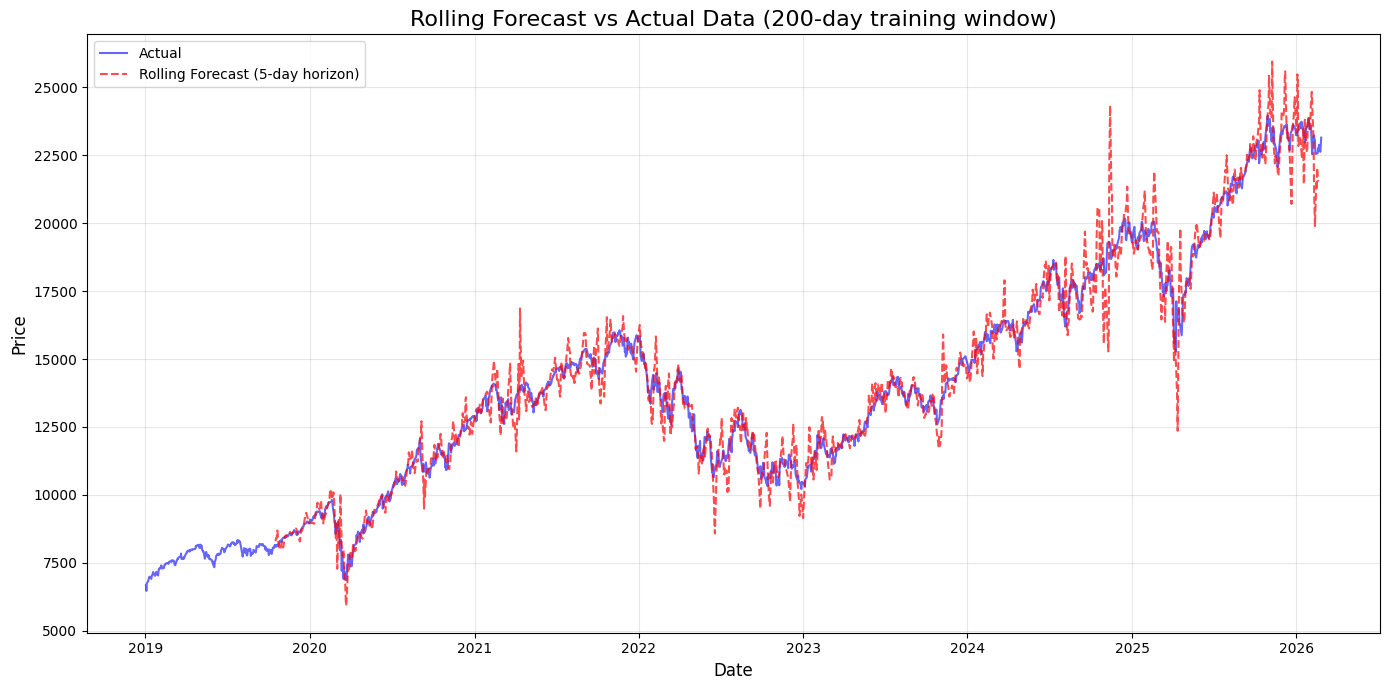

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))


plt.plot(rolling_df['ds'], rolling_df['y'], label='Actual', color='blue', alpha=0.6)


plt.plot(rolling_forecast_results['ds'], rolling_forecast_results['yhat'],
         label='Rolling Forecast (5-day horizon)', color='red', alpha=0.7, linestyle='--')

plt.title('Rolling Forecast vs Actual Data (200-day training window)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()